# **_Access and Plot Northern Hemisphere Sea Ice from Zarr Data Storage_**

The objective if this notebook is to demonstrate the loading and plotting of a CCI sea ice coverage dataset.

This notebook builds upon notebook #5 from the [ESA CCI Toolbox: 5-ECY_Zarr_Access.ipynb](https://github.com/esa-cci/esa-climate-toolbox/blob/main/notebooks/5-ECT_Zarr_Access.ipynb) to visualse Sea Ice in the Northern Hemisphere, using data from Cryosat-2.

The notebook:

- accesses and loads the dataset from the `esa-cci-zarr` zarr storage
- plots a single time step if sea ice thickness
- creates a GIF of a sea ice thickness time series
- plots sea ice thickness and concentration

## **_Access and Load Data_**

#### Import necessary librarires

In [41]:
from xcube.core.store import new_data_store

%matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt

#### Set data storage to `esa-cci-zarr`

In [42]:
zarr_store = new_data_store('esa-cci-zarr')

#### Access specific dataset

We access the `ESACCI-SEAICE-L3C-SITHICK-SIRAL_CRYOSAT2-NH25KMEASE2-2010-2017-fv2.0.zarr` dataset from the Zarr data store. (Other datasets can be found using the [`1-ECT_Finding_Data`](https://github.com/esa-cci/esa-climate-toolbox/blob/main/notebooks/1-ECT_Finding_Data.ipynb) notebook.)

This is a six-year sea ice thickness dataset covering the northern hemisphere. This dataset was produced by the [ESA CCI Sea Ice Project](https://climate.esa.int/en/projects/sea-ice/), and more details on the `ESACCI-SEAICE-L3C-SITHICK-SIRAL_CRYOSAT2-NH25KMEASE2-2010-2017-fv2.0` dataset can be [found here](https://catalogue.ceda.ac.uk/uuid/5b6033bfb7f241e89132a83fdc3d5364/).

More information from the dataset `attrs` is displayed below.

In [43]:
import json

# Assuming this is how you get the data from zarr_store.describe_data()
response = zarr_store.describe_data('ESACCI-SEAICE-L3C-SITHICK-SIRAL_CRYOSAT2-NH25KMEASE2-2010-2017-fv2.0.zarr')

# If the response has a method to_dict() or equivalent, use it.
# Convert the response to a dictionary-like structure
response_dict = response.to_dict() if hasattr(response, 'to_dict') else dict(response)

# Format and display the response with indentation
formatted_response = json.dumps(response_dict, indent=4)

# Display formatted response
print(formatted_response)


{
    "data_id": "ESACCI-SEAICE-L3C-SITHICK-SIRAL_CRYOSAT2-NH25KMEASE2-2010-2017-fv2.0.zarr",
    "data_type": "dataset",
    "bbox": [
        -5400.0,
        -5400.0,
        5400.0,
        5400.0
    ],
    "time_range": [
        "2010-11-01",
        "2017-04-30"
    ],
    "dims": {
        "time": 48,
        "yc": 432,
        "xc": 432,
        "nv": 2
    },
    "coords": {
        "lat": {
            "name": "lat",
            "dtype": "float64",
            "dims": [
                "yc",
                "xc"
            ],
            "chunks": [
                432,
                432
            ],
            "attrs": {
                "long_name": "latitude of grid cell center",
                "standard_name": "latitude",
                "units": "degrees_north"
            }
        },
        "lon": {
            "name": "lon",
            "dtype": "float64",
            "dims": [
                "yc",
                "xc"
            ],
            "chunks": [


#### Open a data cube for this dataset

In [44]:
cube = zarr_store.open_data('ESACCI-SEAICE-L3C-SITHICK-SIRAL_CRYOSAT2-NH25KMEASE2-2010-2017-fv2.0.zarr')
cube

<xarray.Dataset> Size: 263MB
Dimensions:                        (time: 48, yc: 432, xc: 432, nv: 2)
Coordinates:
    lat                            (yc, xc) float64 1MB dask.array<chunksize=(432, 432), meta=np.ndarray>
    lon                            (yc, xc) float64 1MB dask.array<chunksize=(432, 432), meta=np.ndarray>
  * time                           (time) datetime64[ns] 384B 2010-11-01 ... ...
    time_bnds                      (time, nv) datetime64[ns] 768B dask.array<chunksize=(24, 2), meta=np.ndarray>
  * xc                             (xc) float64 3kB -5.388e+03 ... 5.388e+03
  * yc                             (yc) float64 3kB 5.388e+03 ... -5.388e+03
Dimensions without coordinates: nv
Data variables:
    Lambert_Azimuthal_Grid         int8 1B ...
    freeboard                      (time, yc, xc) float32 36MB dask.array<chunksize=(24, 432, 432), meta=np.ndarray>
    freeboard_uncertainty          (time, yc, xc) float32 36MB dask.array<chunksize=(24, 432, 432), meta=np.ndarray>
    radar_freeboard                (time, yc, xc) float32 36MB dask.array<chunksize=(24, 432, 432), meta=np.ndarray>
    radar_freeboard_uncertainty    (time, yc, xc) float32 36MB dask.array<chunksize=(24, 432, 432), meta=np.ndarray>
    sea_ice_concentration          (time, yc, xc) float32 36MB dask.array<chunksize=(24, 432, 432), meta=np.ndarray>
    sea_ice_thickness              (time, yc, xc) float32 36MB dask.array<chunksize=(24, 432, 432), meta=np.ndarray>
    sea_ice_thickness_uncertainty  (time, yc, xc) float32 36MB dask.array<chunksize=(24, 432, 432), meta=np.ndarray>
    status_flag                    (time, yc, xc) int8 9MB dask.array<chunksize=(24, 432, 432), meta=np.ndarray>
Attributes: (12/37)
    cdm_data_type:             Grid
    comment:                   Northern hemisphere sea ice thickness coverage...
    conventions:               CF-1.6
    creator_email:             stefan.hendricks@awi.de, stephan.paul@awi.de, ...
    creator_name:              Stefan Hendricks, Stephan Paul (Alfred Wegener...
    creator_url:               http://www.awi.de
    ...                        ...
    time_coverage_duration:    P1M
    time_coverage_end:         19700101T000001
    time_coverage_resolution:  P1M
    time_coverage_start:       19700101T000001
    title:                     ESA Climate Change Initiative Sea Ice: Norther...
    tracking_id:               6a71bb60-e10b-4dca-a50c-c79a13bc3393

## **_Visualising the data_**

We visualise the data by:

- plotting a single time step
- creating a GIF of a time series
- charting sea ice thickness and concentration

### **Plot a single time step**

#### Import the necessary libraries

In [45]:
import matplotlib.pyplot as plt

#### Create the plot


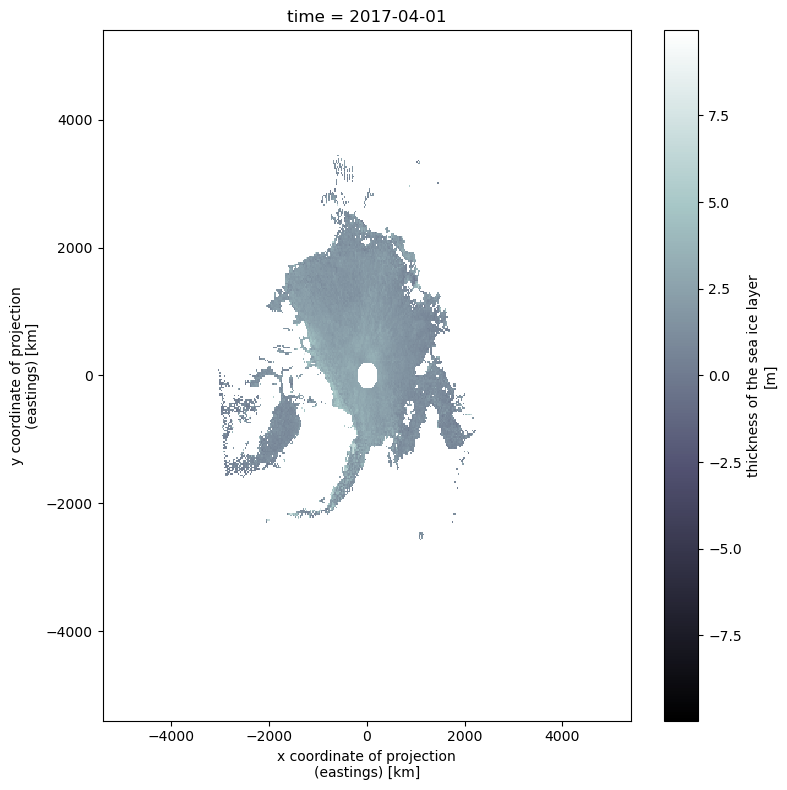

In [46]:
cube.sea_ice_thickness.sel(time='2017-11-01 12:00:00', method='nearest').plot.imshow(cmap='bone', figsize=(8, 8))
plt.show()
plt.close()

### **Create a GIF**

To visualse how the sea ice changes over the dataset period, we create an animated gif, plotting each time point in the dataset. The gif image will be saved locally.

#### Install the required libraries

In [47]:
!pip install imageio

Defaulting to user installation because normal site-packages is not writeable


#### Get the times from the data cube

In [48]:
times = cube.time

#### Import necessary libraries and create GIF

The GIF will be created in memory, and then stored as specified in `gif_filename`.

Note: the runtime of this cell can be several minutes.

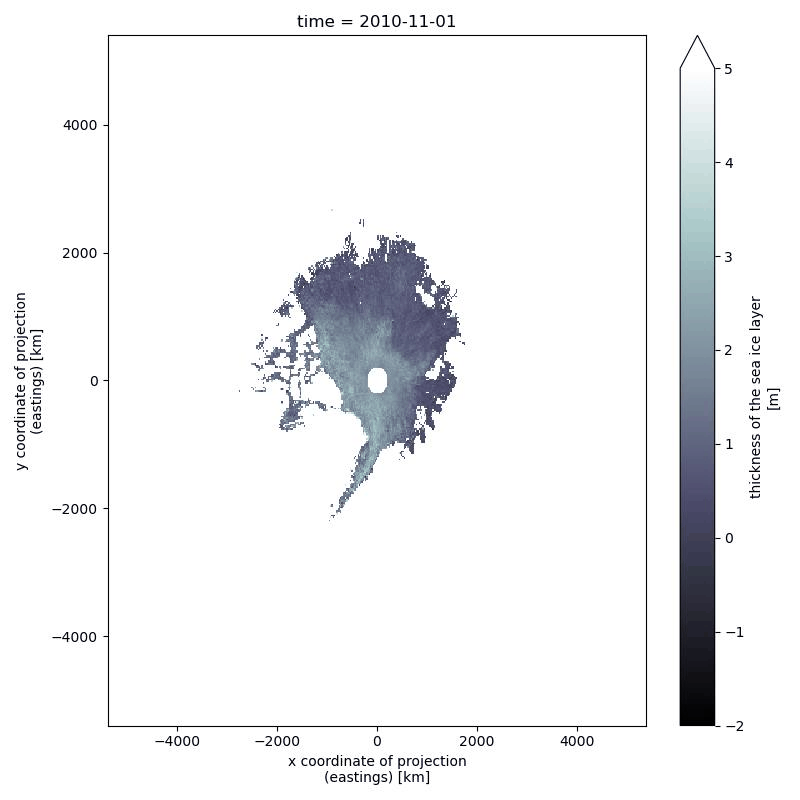

In [49]:
# Import necessary libraries
import imageio
import matplotlib.pyplot as plt
from io import BytesIO
import warnings
import os

# Suppress warnings
warnings.filterwarnings('ignore')

# Parameters
delay = 1.0  # Delay between frames in seconds

# Ensure the 'output' directory exists
output_dir = 'output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Generate plots for the whole timeseries and store them in memory
images = []

for i in range(len(times)):
    t = times[i]
    fig, ax = plt.subplots(figsize=(8, 8))
    cube.sea_ice_thickness.sel(time=t, method='nearest').plot.imshow(cmap='bone', ax=ax, vmin=-2, vmax=5)
    buf = BytesIO()
    plt.savefig(buf, format='jpg')
    buf.seek(0)
    images.append(imageio.imread(buf))
    plt.close(fig)

# Create the animated GIF from the images in the 'output' folder
gif_filename = os.path.join(output_dir, 'CCI-SeaIce-Animation.gif')
imageio.mimsave(gif_filename, images, duration=delay)

# Display the animated GIF in the notebook
from IPython.display import Image
Image(filename=gif_filename)


### **Plotting the time series**
Plot the average sea ice thickness and sea ice concentration at each time point over the perio.

The below builds off notebook 8 in the ESA CCI Toolbox: [`8-ECT_Using_Operations.ipynb`](https://github.com/esa-cci/esa-climate-toolbox/blob/main/notebooks/8-ECT_Using_Operations.ipynb).

#### Install necessary libraries

In [50]:
import esa_climate_toolbox.ops as ops

from esa_climate_toolbox.core import get_op
from esa_climate_toolbox.core import get_op_meta_info
from esa_climate_toolbox.util.monitor import ConsoleMonitor

#### Select variables

In [51]:
svar_op = get_op('select_var')

seaice_concentration_ds = svar_op(ds=cube, var='sea_ice_concentration')
seaice_concentration_ds

seaice_thickness_ds = svar_op(ds=cube, var='sea_ice_thickness')
seaice_thickness_ds

<xarray.Dataset> Size: 39MB
Dimensions:            (yc: 432, xc: 432, time: 48, nv: 2)
Coordinates:
    lat                (yc, xc) float64 1MB dask.array<chunksize=(432, 432), meta=np.ndarray>
    lon                (yc, xc) float64 1MB dask.array<chunksize=(432, 432), meta=np.ndarray>
  * time               (time) datetime64[ns] 384B 2010-11-01 ... 2017-04-01
    time_bnds          (time, nv) datetime64[ns] 768B dask.array<chunksize=(24, 2), meta=np.ndarray>
  * xc                 (xc) float64 3kB -5.388e+03 -5.362e+03 ... 5.388e+03
  * yc                 (yc) float64 3kB 5.388e+03 5.362e+03 ... -5.388e+03
Dimensions without coordinates: nv
Data variables:
    sea_ice_thickness  (time, yc, xc) float32 36MB dask.array<chunksize=(24, 432, 432), meta=np.ndarray>
Attributes: (12/37)
    cdm_data_type:             Grid
    comment:                   Northern hemisphere sea ice thickness coverage...
    conventions:               CF-1.6
    creator_email:             stefan.hendricks@awi.de, stephan.paul@awi.de, ...
    creator_name:              Stefan Hendricks, Stephan Paul (Alfred Wegener...
    creator_url:               http://www.awi.de
    ...                        ...
    time_coverage_duration:    P1M
    time_coverage_end:         19700101T000001
    time_coverage_resolution:  P1M
    time_coverage_start:       19700101T000001
    title:                     ESA Climate Change Initiative Sea Ice: Norther...
    tracking_id:               6a71bb60-e10b-4dca-a50c-c79a13bc3393

#### Set timeseries parameters

In [52]:
tseries_point_op = get_op('tseries_point')
tseries_mean_op = get_op('tseries_mean')

#### Compute mean timeseries

In [53]:
seaice_thickness_mean = tseries_mean_op(seaice_thickness_ds, var='sea_ice_thickness')
seaice_concentration_mean = tseries_mean_op(seaice_concentration_ds, var='sea_ice_concentration')

#### Plot mean timeseries

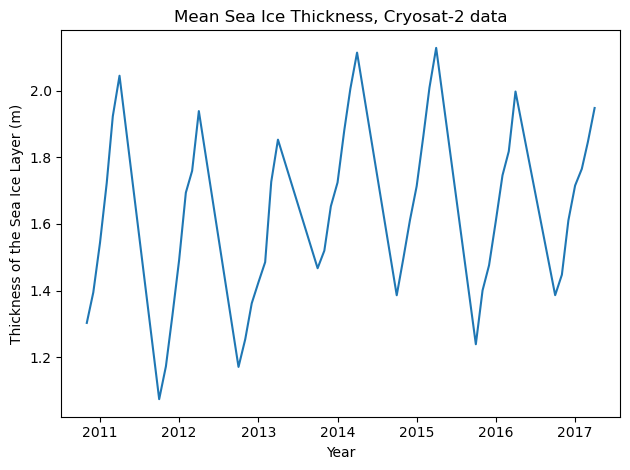

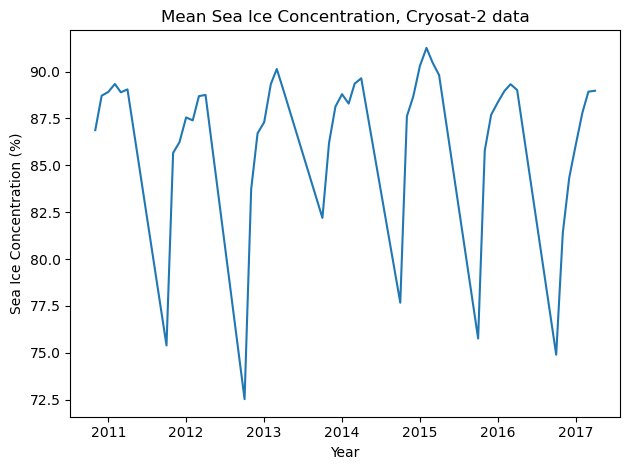

In [54]:
%matplotlib inline

seaice_thickness_mean.sea_ice_thickness_mean.plot()
plt.title("Mean Sea Ice Thickness, Cryosat-2 data")
plt.xlabel("Year")
plt.ylabel("Thickness of the Sea Ice Layer (m)")
plt.show()
plt.close()

seaice_concentration_mean.sea_ice_concentration_mean.plot()
plt.title("Mean Sea Ice Concentration, Cryosat-2 data")
plt.xlabel("Year")
plt.ylabel("Sea Ice Concentration (%)")
plt.show()
plt.close()